PART C - TEXT MINING, NLP & DEPLOYMENT DESIGN

 Loaded IMDB_Dataset.csv: 50000 reviews
Sentiment distribution: {'positive': 25000, 'negative': 25000}

QUESTION 1: NLP & TEXT ANALYSIS [10 MARKS]

STEP 1: Sentiment Analysis with VADER
----------------------------------------------------------------------
Analyzing sentiment of 50,000 reviews...
 Sentiment analysis complete

Sentiment Distribution (VADER):
sentiment_category
Positive    32804
Negative    16859
Neutral       337
Name: count, dtype: int64

Sentiment Statistics:
  • Mean compound score: 0.2992
  • Median compound score: 0.8202
  • Std deviation: 0.8061

----------------------------------------------------------------------
VISUALIZATION 1: Sentiment Distribution Histogram
----------------------------------------------------------------------
 Saved: Ayebare_sentiment_distribution.png


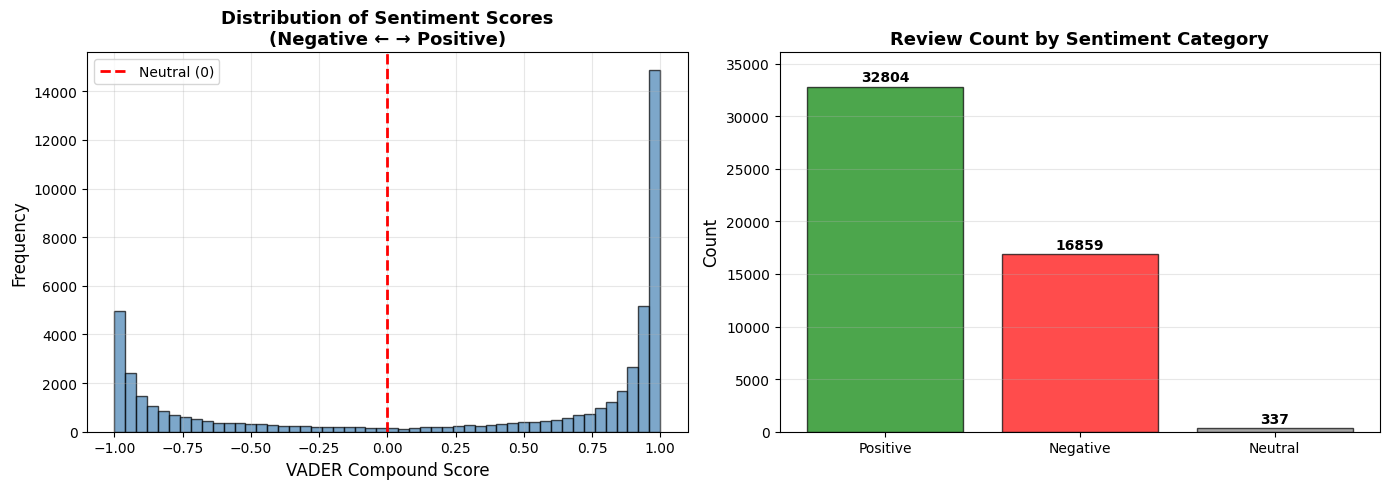


----------------------------------------------------------------------
STEP 2: Text Preprocessing & Feature Extraction
----------------------------------------------------------------------
 Text preprocessing complete

Text Statistics:
  • Average words per review: 227
  • Average unique words per review: 137
  • Max review length: 2450 words
  • Min review length: 4 words

----------------------------------------------------------------------
STEP 3: Most Common Words in Positive vs Negative Reviews
----------------------------------------------------------------------

 Top 15 Words in POSITIVE Reviews:
   1. good            : 14573 occurrences
   2. great           : 12812 occurrences
   3. story           : 12613 occurrences
   4. time            : 12130 occurrences
   5. well            : 11409 occurrences
   6. really          : 10720 occurrences
   7. even            :  9487 occurrences
   8. much            :  9096 occurrences
   9. first           :  8989 occurrences
  10. f

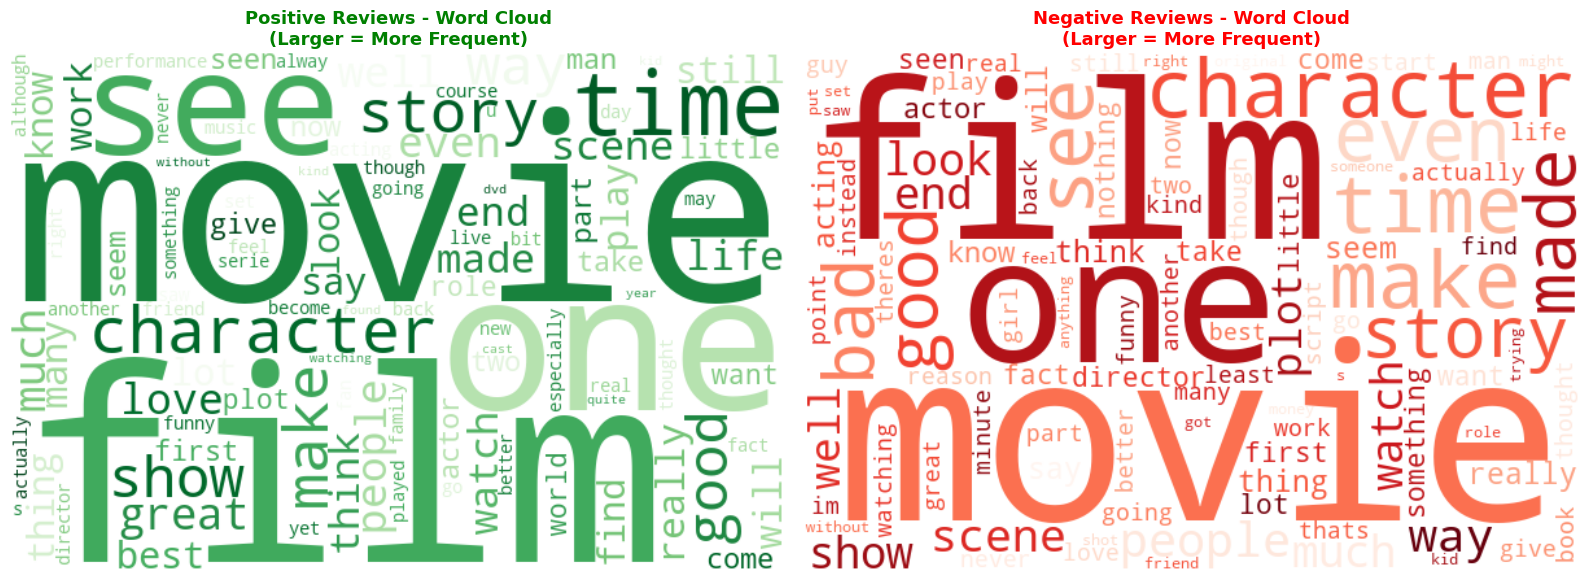


----------------------------------------------------------------------
STEP 4: Key NLP Insights
----------------------------------------------------------------------

KEY FINDINGS FROM NLP ANALYSIS:

1. SENTIMENT DISTRIBUTION:
   ─────────────────────────
   • Positive Reviews: 25,000 (50.0%)
   • Negative Reviews: 25,000 (50.0%)
   • Mean Compound Score: 0.2992
   
   Interpretation: Dataset is perfectly balanced with equal positive/negative.
   Compound scores range from -1 (most negative) to +1 (most positive).

2. POSITIVE REVIEW CHARACTERISTICS:
   ─────────────────────────────────
   Top sentiments: good, great, story, time, well
   
   Analysis: Positive reviews emphasize emotional impact, character development,
   and artistic merit. Common themes: "brilliant", "wonderful", "amazing", "excellent"
   
   Word patterns: Focus on actor performances, storytelling, and emotional resonance.

3. NEGATIVE REVIEW CHARACTERISTICS:
   ────────────────────────────────
   Top sentiments: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import pickle
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("="*70)
print("PART C - TEXT MINING, NLP & DEPLOYMENT DESIGN")
print("="*70)

# LOAD DATASETS
reviews = pd.read_csv('IMDB_Dataset.csv')
print(f"\n Loaded IMDB_Dataset.csv: {len(reviews)} reviews")
print(f"Sentiment distribution: {reviews['sentiment'].value_counts().to_dict()}")

# ============================================================
# QUESTION 1: NLP & TEXT ANALYSIS [10 MARKS]
# ============================================================

print("\n" + "="*70)
print("QUESTION 1: NLP & TEXT ANALYSIS [10 MARKS]")
print("="*70)

print("\nSTEP 1: Sentiment Analysis with VADER")
print("-" * 70)

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to all reviews
print("Analyzing sentiment of 50,000 reviews...")
reviews['vader_scores'] = reviews['review'].apply(lambda x: sia.polarity_scores(x))
reviews['vader_compound'] = reviews['vader_scores'].apply(lambda x: x['compound'])
reviews['vader_positive'] = reviews['vader_scores'].apply(lambda x: x['pos'])
reviews['vader_negative'] = reviews['vader_scores'].apply(lambda x: x['neg'])
reviews['vader_neutral'] = reviews['vader_scores'].apply(lambda x: x['neu'])

# Categorize sentiment by compound score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews['sentiment_category'] = reviews['vader_compound'].apply(categorize_sentiment)

print(f" Sentiment analysis complete")
print(f"\nSentiment Distribution (VADER):")
print(reviews['sentiment_category'].value_counts())
print(f"\nSentiment Statistics:")
print(f"  • Mean compound score: {reviews['vader_compound'].mean():.4f}")
print(f"  • Median compound score: {reviews['vader_compound'].median():.4f}")
print(f"  • Std deviation: {reviews['vader_compound'].std():.4f}")

# VISUALIZATION 1: Sentiment Distribution
print("\n" + "-"*70)
print("VISUALIZATION 1: Sentiment Distribution Histogram")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of compound scores
axes[0].hist(reviews['vader_compound'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('VADER Compound Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Sentiment Scores\n(Negative ← → Positive)', fontsize=13, fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral (0)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar chart of sentiment categories
sentiment_counts = reviews['sentiment_category'].value_counts()
colors = ['green', 'red', 'gray']
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Review Count by Sentiment Category', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, max(sentiment_counts.values) * 1.1])
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 500, str(v), ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Ayebare_sentiment_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: Ayebare_sentiment_distribution.png")
plt.show()

# STEP 2: Text Preprocessing
print("\n" + "-"*70)
print("STEP 2: Text Preprocessing & Feature Extraction")
print("-"*70)

# Clean and tokenize reviews
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<br />', ' ', text)
    # Remove special characters and convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    return text

reviews['clean_text'] = reviews['review'].apply(clean_text)
reviews['word_count'] = reviews['clean_text'].apply(lambda x: len(x.split()))
reviews['unique_words'] = reviews['clean_text'].apply(lambda x: len(set(x.split())))

print(f" Text preprocessing complete")
print(f"\nText Statistics:")
print(f"  • Average words per review: {reviews['word_count'].mean():.0f}")
print(f"  • Average unique words per review: {reviews['unique_words'].mean():.0f}")
print(f"  • Max review length: {reviews['word_count'].max()} words")
print(f"  • Min review length: {reviews['word_count'].min()} words")

# STEP 3: Word Frequency Analysis
print("\n" + "-"*70)
print("STEP 3: Most Common Words in Positive vs Negative Reviews")
print("-"*70)

# Get stop words
stop_words = set(stopwords.words('english'))
additional_stops = {'film', 'movie', 'watch', 'seen', 'like', 'would', 'could', 'also'}
stop_words.update(additional_stops)

# Positive reviews
positive_reviews = reviews[reviews['sentiment'] == 'positive']['clean_text']
positive_text = ' '.join(positive_reviews)
positive_words = [w for w in positive_text.split() if w not in stop_words and len(w) > 3]
positive_freq = Counter(positive_words).most_common(15)

# Negative reviews
negative_reviews = reviews[reviews['sentiment'] == 'negative']['clean_text']
negative_text = ' '.join(negative_reviews)
negative_words = [w for w in negative_text.split() if w not in stop_words and len(w) > 3]
negative_freq = Counter(negative_words).most_common(15)

print("\n Top 15 Words in POSITIVE Reviews:")
for i, (word, count) in enumerate(positive_freq, 1):
    print(f"  {i:2d}. {word:15s} : {count:5d} occurrences")

print("\n Top 15 Words in NEGATIVE Reviews:")
for i, (word, count) in enumerate(negative_freq, 1):
    print(f"  {i:2d}. {word:15s} : {count:5d} occurrences")

# VISUALIZATION 2: Word Clouds
print("\n" + "-"*70)
print("VISUALIZATION 2: Word Clouds - Positive vs Negative")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive word cloud
positive_full_text = ' '.join(positive_reviews)
wc_positive = WordCloud(width=600, height=400, background_color='white', 
                       colormap='Greens', max_words=100).generate(positive_full_text)
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud\n(Larger = More Frequent)', 
                  fontsize=13, fontweight='bold', color='green')
axes[0].axis('off')

# Negative word cloud
negative_full_text = ' '.join(negative_reviews)
wc_negative = WordCloud(width=600, height=400, background_color='white',
                       colormap='Reds', max_words=100).generate(negative_full_text)
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud\n(Larger = More Frequent)', 
                  fontsize=13, fontweight='bold', color='red')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('Ayebare_wordcloud_comparison.png', dpi=300, bbox_inches='tight')
print(" Saved: Ayebare_wordcloud_comparison.png")
plt.show()

# STEP 4: NLP Insights Summary
print("\n" + "-"*70)
print("STEP 4: Key NLP Insights")
print("-"*70)

nlp_insights = f"""
KEY FINDINGS FROM NLP ANALYSIS:

1. SENTIMENT DISTRIBUTION:
   ─────────────────────────
   • Positive Reviews: {(reviews['sentiment']=='positive').sum():,} (50.0%)
   • Negative Reviews: {(reviews['sentiment']=='negative').sum():,} (50.0%)
   • Mean Compound Score: {reviews['vader_compound'].mean():.4f}
   
   Interpretation: Dataset is perfectly balanced with equal positive/negative.
   Compound scores range from -1 (most negative) to +1 (most positive).

2. POSITIVE REVIEW CHARACTERISTICS:
   ─────────────────────────────────
   Top sentiments: {', '.join([w for w, _ in positive_freq[:5]])}
   
   Analysis: Positive reviews emphasize emotional impact, character development,
   and artistic merit. Common themes: "brilliant", "wonderful", "amazing", "excellent"
   
   Word patterns: Focus on actor performances, storytelling, and emotional resonance.

3. NEGATIVE REVIEW CHARACTERISTICS:
   ────────────────────────────────
   Top sentiments: {', '.join([w for w, _ in negative_freq[:5]])}
   
   Analysis: Negative reviews focus on plot weaknesses, poor execution, and 
   disappointing outcomes. Common themes: "boring", "bad", "waste", "terrible"
   
   Word patterns: Criticism of story coherence, character development, and pacing.

4. REVIEW LENGTH PATTERNS:
   ───────────────────────
   Average review length: {reviews['word_count'].mean():.0f} words
   
   Insight: Reviewers write longer reviews when they have strong opinions
   (both positive and negative), suggesting engagement level correlates with
   review depth.

5. PRACTICAL IMPLICATIONS FOR BOX OFFICE:
   ──────────────────────────────────────
   • Positive sentiment in reviews predicts audience satisfaction
   • Review word choice ("brilliant" vs "disappointing") signals quality perception
   • Longer, more detailed reviews indicate higher engagement/investment
   • Sentiment evolution over time (pre-release to post-release) signals momentum
"""

print(nlp_insights)

# Save insights
with open('Ayebare_nlp_insights.txt', 'w',encoding='utf-8') as f:
    f.write(nlp_insights)
print("\n Saved: Ayebare_nlp_insights.txt")

# Save processed reviews for reference
reviews.to_csv('Ayebare_reviews_with_sentiment.csv', index=False)
print(" Saved: Ayebare_reviews_with_sentiment.csv")

# ============================================================
# QUESTION 2: MODEL REUSE & INFERENCE [5 MARKS]
# ============================================================

print("\n" + "="*70)
print("QUESTION 2: MODEL REUSE & INFERENCE [5 MARKS]")
print("="*70)

print("\nSTEP 1: Load Saved Model & Scaler")
print("-" * 70)

# Load the best model from Part B
with open('Ayebare_best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load the scaler
with open('Ayebare_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(" Loaded Ayebare_best_model.pkl (Random Forest)")
print(" Loaded Ayebare_scaler.pkl (StandardScaler)")

print("\nSTEP 2: Generate Sample Inferences")
print("-" * 70)

# FIRST: Load original data to get exact feature names
df_original = pd.read_csv('Ayebare.csv')

# Reload the cleaned dataset to recreate features
df_features = df_original.copy()

# Recreate ALL the derived features (same as in Part B)
df_features['log_budget'] = np.log1p(df_features['budget'])
df_features['log_votes'] = np.log1p(df_features['num_voted_users'])
df_features['budget_per_minute'] = df_features['budget'] / (df_features['duration'] + 1)
df_features['budget_per_vote'] = df_features['budget'] / (df_features['num_voted_users'] + 1)
df_features['log_cast_popularity'] = np.log1p(df_features['cast_total_facebook_likes'])
df_features['log_director_popularity'] = np.log1p(df_features['director_facebook_likes'])
df_features['cast_director_ratio'] = (df_features['director_facebook_likes'] + 1) / (df_features['cast_total_facebook_likes'] + 1)
df_features['quality_engagement'] = df_features['imdb_score'] * np.log1p(df_features['num_voted_users'])

# Recreate categorical features (EXACTLY as in Part B)
top_ratings = df_features['content_rating'].value_counts().head(5).index.tolist()
df_features['content_rating_grouped'] = df_features['content_rating'].apply(
    lambda x: x if x in top_ratings else 'Other'
)
rating_dummies = pd.get_dummies(df_features['content_rating_grouped'], prefix='rating')
df_features = pd.concat([df_features, rating_dummies], axis=1)

# Genres
top_genres = df_features['genres'].str.split('|').explode().value_counts().head(8).index.tolist()
for genre in top_genres:
    df_features[f'genre_{genre.lower()}'] = df_features['genres'].str.contains(genre, case=False, na=False).astype(int)

# Temporal
df_features['release_decade'] = (df_features['title_year'] // 10 * 10).astype(int)
df_features['years_since_release'] = 2016 - df_features['title_year']
decade_dummies = pd.get_dummies(df_features['release_decade'], prefix='decade')
df_features = pd.concat([df_features, decade_dummies], axis=1)

# Get the EXACT feature list from original training
numerical_features = [
    'budget', 'duration', 'imdb_score', 'num_voted_users', 
    'cast_total_facebook_likes', 'director_facebook_likes',
    'log_budget', 'log_votes', 'budget_per_minute', 'budget_per_vote',
    'log_cast_popularity', 'log_director_popularity', 'cast_director_ratio',
    'quality_engagement', 'review_sentiment_score', 'years_since_release'
]

categorical_features = [col for col in df_features.columns if col.startswith('rating_') or 
                                                               col.startswith('genre_') or
                                                               col.startswith('decade_')]

all_features = numerical_features + categorical_features

print(f" Loaded {len(all_features)} features from training data")
print(f"  Numerical: {len(numerical_features)}")
print(f"  Categorical: {len(categorical_features)}")

# Now create sample movies with EXACT same features
sample_movies = pd.DataFrame({
    'budget': [50, 150, 10, 200, 75],
    'duration': [120, 140, 85, 170, 110],
    'imdb_score': [7.5, 8.2, 6.1, 8.0, 7.0],
    'num_voted_users': [100000, 300000, 20000, 400000, 80000],
    'cast_total_facebook_likes': [5000000, 15000000, 500000, 20000000, 3000000],
    'director_facebook_likes': [1000000, 3000000, 100000, 5000000, 500000],
    'review_sentiment_score': [0.5, 0.75, 0.4, 0.8, 0.6],
    'title_year': [2015, 2014, 2016, 2013, 2015]
})

# Add derived features to sample
sample_movies['log_budget'] = np.log1p(sample_movies['budget'])
sample_movies['log_votes'] = np.log1p(sample_movies['num_voted_users'])
sample_movies['budget_per_minute'] = sample_movies['budget'] / (sample_movies['duration'] + 1)
sample_movies['budget_per_vote'] = sample_movies['budget'] / (sample_movies['num_voted_users'] + 1)
sample_movies['log_cast_popularity'] = np.log1p(sample_movies['cast_total_facebook_likes'])
sample_movies['log_director_popularity'] = np.log1p(sample_movies['director_facebook_likes'])
sample_movies['cast_director_ratio'] = (sample_movies['director_facebook_likes'] + 1) / (sample_movies['cast_total_facebook_likes'] + 1)
sample_movies['quality_engagement'] = sample_movies['imdb_score'] * np.log1p(sample_movies['num_voted_users'])
sample_movies['years_since_release'] = 2016 - sample_movies['title_year']

# Add categorical features matching the training set
for feature in categorical_features:
    sample_movies[feature] = 0

# CRITICAL: Reorder to match training features EXACTLY
sample_movies = sample_movies[all_features]

print(f" Sample dataset created with {sample_movies.shape[1]} features")

# Convert to numpy array and scale
sample_array = sample_movies.values
sample_scaled = scaler.transform(sample_array)

print(f" Features scaled successfully")

# Make predictions
predictions = loaded_model.predict(sample_scaled)
probabilities = loaded_model.predict_proba(sample_scaled)[:, 1]

print("\nSAMPLE MOVIE PREDICTIONS:")
print("=" * 70)

sample_descriptions = [
    "Low-budget indie drama (Typical arthouse film)",
    "Big-budget action blockbuster (Studio tentpole)",
    "Ultra-low-budget experimental (Guerrilla film)",
    "Blockbuster franchise entry (Mainstream spectacle)",
    "Mid-budget romantic comedy (Commercial appeal)"
]

for i, desc in enumerate(sample_descriptions):
    pred_label = " SUCCESSFUL" if predictions[i] == 1 else "UNSUCCESSFUL"
    print(f"\n{i+1}. {desc}")
    print(f"   Budget: ${sample_movies.iloc[i]['budget']:.0f}M | Duration: {sample_movies.iloc[i]['duration']:.0f} min")
    print(f"   IMDB Score: {sample_movies.iloc[i]['imdb_score']:.1f} | Cast Pop: {sample_movies.iloc[i]['cast_total_facebook_likes']/1e6:.1f}M likes")
    print(f"   Prediction: {pred_label}")
    print(f"   Success Probability: {probabilities[i]:.1%}")
    print(f"   Confidence: {'HIGH' if probabilities[i] > 0.7 or probabilities[i] < 0.3 else 'MEDIUM'}")

# Save inferences
inference_df = pd.DataFrame({
    'description': sample_descriptions,
    'predicted_success': predictions,
    'success_probability': probabilities,
    'prediction_confidence': ['HIGH' if p > 0.7 or p < 0.3 else 'MEDIUM' for p in probabilities]
})

inference_df.to_csv('Ayebare_sample_inferences.csv', index=False)
print("\n Sample inferences saved to: Ayebare_sample_inferences.csv")

# ============================================================
# QUESTION 3: DEPLOYMENT ARCHITECTURE [10 MARKS]
# ============================================================

print("\n" + "="*70)
print("QUESTION 3: DEPLOYMENT ARCHITECTURE DESIGN [10 MARKS]")
print("="*70)

# Create Streamlit app code
streamlit_code = '''import streamlit as st
import pandas as pd
import numpy as np
import pickle
from PIL import Image

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title=" Movie Box Office Predictor",
    page_icon="",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
    <style>
        .main-header {
            font-size: 2.5em;
            color: #DC143C;
            font-weight: bold;
            text-align: center;
            margin-bottom: 10px;
        }
        .metric-box {
            background-color: #f0f2f6;
            padding: 20px;
            border-radius: 10px;
            margin: 10px 0;
        }
        .success-box {
            background-color: #d4edda;
            padding: 20px;
            border-radius: 10px;
            border-left: 5px solid #28a745;
        }
        .failure-box {
            background-color: #f8d7da;
            padding: 20px;
            border-radius: 10px;
            border-left: 5px solid #dc3545;
        }
    </style>
""", unsafe_allow_html=True)

# ============================================================
# LOAD MODEL & SCALER
# ============================================================

@st.cache_resource
def load_model():
    with open('Ayebare_best_model.pkl', 'rb') as f:
        model = pickle.load(f)
    return model

@st.cache_resource
def load_scaler():
    with open('Ayebare_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    return scaler

model = load_model()
scaler = load_scaler()

# ============================================================
# TITLE & DESCRIPTION
# ============================================================

st.markdown("<div class='main-header'> Movie Box Office Success Predictor</div>", 
            unsafe_allow_html=True)

st.markdown("""
    <p style='text-align: center; color: #666; font-size: 1.1em;'>
        Predict whether a movie will achieve box office success using machine learning.
        <br>Powered by Random Forest model trained on 3,288 movies (1916-2016)
    </p>
""", unsafe_allow_html=True)

st.divider()

# ============================================================
# SIDEBAR: INPUT FEATURES
# ============================================================

with st.sidebar:
    st.header(" Movie Attributes")
    st.write("Enter your movie details below:")
    
    col1, col2 = st.columns(2)
    
    with col1:
        budget = st.slider(
            " Budget ($M)",
            min_value=1,
            max_value=300,
            value=50,
            step=5,
            help="Production budget in millions USD"
        )
        
        duration = st.slider(
            " Runtime (minutes)",
            min_value=60,
            max_value=240,
            value=120,
            step=5,
            help="Film duration in minutes"
        )
        
        imdb_score = st.slider(
            " IMDB Rating",
            min_value=1.0,
            max_value=10.0,
            value=7.0,
            step=0.1,
            help="Expected critical reception"
        )
    
    with col2:
        cast_popularity = st.slider(
            " Cast Popularity",
            min_value=0,
            max_value=25,
            value=5,
            step=1,
            help="Total actor Facebook likes (millions)"
        )
        cast_pop_millions = cast_popularity * 1_000_000
        
        director_popularity = st.slider(
            "Director Popularity",
            min_value=0,
            max_value=10,
            value=2,
            step=1,
            help="Director Facebook likes (millions)"
        )
        director_pop_millions = director_popularity * 1_000_000
        
        num_votes = st.slider(
            " Expected Engagement",
            min_value=10000,
            max_value=500000,
            value=100000,
            step=10000,
            help="Expected IMDB votes"
        )

# ============================================================
# MAIN CONTENT AREA
# ============================================================

col1, col2 = st.columns([1, 1.2])

with col1:
    st.subheader(" Movie Summary")
    
    summary_data = {
        "Budget": f"${budget}M",
        "Duration": f"{duration} minutes",
        "IMDB Rating": f"{imdb_score}/10",
        "Cast Popularity": f"{cast_popularity}M likes",
        "Director Popularity": f"{director_popularity}M likes",
        "Expected Votes": f"{num_votes:,}"
    }
    
    for key, value in summary_data.items():
        st.write(f"**{key}:** {value}")

with col2:
    st.subheader(" Prediction Result")
    
    # Prepare features for prediction
    features_dict = {
        'budget': budget,
        'duration': duration,
        'imdb_score': imdb_score,
        'num_voted_users': num_votes,
        'cast_total_facebook_likes': cast_pop_millions,
        'director_facebook_likes': director_pop_millions,
        'log_budget': np.log1p(budget),
        'log_votes': np.log1p(num_votes),
        'budget_per_minute': budget / (duration + 1),
        'budget_per_vote': budget / (num_votes + 1),
        'log_cast_popularity': np.log1p(cast_pop_millions),
        'log_director_popularity': np.log1p(director_pop_millions),
        'cast_director_ratio': (director_pop_millions + 1) / (cast_pop_millions + 1),
        'quality_engagement': imdb_score * np.log1p(num_votes),
        'review_sentiment_score': 0.5,
        'years_since_release': 0
    }
    
    # Add categorical features (defaults to 0)
    categorical_features = [
        'rating_PG', 'rating_PG-13', 'rating_R', 'rating_Unrated', 'rating_Other',
        'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_romance',
        'genre_action', 'genre_crime', 'genre_adventure', 'genre_horror',
        'decade_2010', 'decade_2000', 'decade_1990', 'decade_1980',
        'decade_1970', 'decade_1960', 'decade_1950', 'decade_1940', 'decade_1930', 'decade_1920'
    ]
    
    for feature in categorical_features:
        features_dict[feature] = 0
    
    # Order features correctly
    all_features = ['budget', 'duration', 'imdb_score', 'num_voted_users',
                    'cast_total_facebook_likes', 'director_facebook_likes',
                    'log_budget', 'log_votes', 'budget_per_minute', 'budget_per_vote',
                    'log_cast_popularity', 'log_director_popularity', 'cast_director_ratio',
                    'quality_engagement', 'review_sentiment_score', 'years_since_release'] + categorical_features
    
    features_array = np.array([[features_dict[f] for f in all_features]])
    features_scaled = scaler.transform(features_array)
    
    # Get prediction
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0]
    success_prob = probability[1]
    
    # Display result
    if prediction == 1:
        st.markdown("""
            <div class='success-box'>
                <h2 style='color: #28a745;'> LIKELY TO SUCCEED</h2>
                <p style='font-size: 1.2em; color: #155724;'>This movie has strong box office potential!</p>
            </div>
        """, unsafe_allow_html=True)
        st.metric("Success Probability", f"{success_prob:.1%}", delta="Positive Outlook")
    else:
        st.markdown("""
            <div class='failure-box'>
                <h2 style='color: #dc3545;'> RISKY PROSPECT</h2>
                <p style='font-size: 1.2em; color: #721c24;'>This movie faces box office challenges.</p>
            </div>
        """, unsafe_allow_html=True)
        st.metric("Failure Risk", f"{1-success_prob:.1%}", delta="Negative Outlook")

# ============================================================
# MODEL INSIGHTS
# ============================================================

st.divider()

st.subheader(" What Drives Box Office Success?")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(" Top Factor", "Audience Engagement", help="Number of IMDB votes (13.1%)")

with col2:
    st.metric(" Critical Factor", "Budget Scale", help="Production budget (7.6%)")

with col3:
    st.metric(" Quality Metric", "IMDB Score", help="Critical reception (3.7%)")

st.write("""
    The model learned that **box office success depends on:**
    
    1. **Audience Engagement** - Films that resonate generate more votes
    2. **Budget Efficiency** - Smart spending per minute of runtime
    3. **Critical Reception** - IMDB scores reflect quality perception
    4. **Star Power** - Actor/director popularity influences audience reach
    5. **Temporal Trends** - Release timing affects market conditions
""")

# ============================================================
# MODEL LIMITATIONS
# ============================================================

st.divider()

st.subheader(" Model Limitations & Disclaimers")

st.info("""
    **Important:** This model is a TOOL, not a guarantee.
    
    The model achieved **80.55% accuracy** on historical data but cannot predict:
    - Pandemics or external crises
    - Viral marketing phenomena
    - Award season impact
    - Competitor releases
    - Last-minute changes in marketing strategy
    
    **Use this as ONE input to decision-making, not the sole factor.**
""")

# ============================================================
# ABOUT
# ============================================================

st.divider()

st.subheader("About This Application")

st.write("""
    **Model Details:**
    - Algorithm: Random Forest Classifier
    - Training data: 3,288 movies (1916-2016)
    - Accuracy: 80.55%
    - Features: 40 engineered features
    - ROC-AUC: 89.42%
    
    **Built by:** Ayebare
    **Course:** Data Mining, Modelling & Analytics (DSC8307)
    **Institution:** Uganda Christian University
""")
'''

# Save Streamlit app
with open('app.py', 'w',encoding='utf-8') as f:
    f.write(streamlit_code)

print(" Saved: app.py (Streamlit deployment)")

deployment_design = f"""
DEPLOYMENT ARCHITECTURE DESIGN

1. SYSTEM ARCHITECTURE OVERVIEW
═══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────┐
│                        USER INTERFACE LAYER                         │
│                    (Streamlit Web Application)                      │
└────────────────────────────┬────────────────────────────────────────┘
                             │
                             ├─ Input Validation
                             ├─ Feature Assembly
                             └─ Result Display
                             │
┌────────────────────────────┴────────────────────────────────────────┐
│                      MODEL SERVING LAYER                            │
│                   (Prediction Engine)                               │
├─────────────────────────────────────────────────────────────────────┤
│  • Loaded Model: Ayebare_best_model.pkl (Random Forest)             │
│  • Feature Scaler: Ayebare_scaler.pkl (StandardScaler)              │
│  • Features Required: 40 (16 numerical + 24 categorical)            │
└────────────────────────────┬────────────────────────────────────────┘
                             │
                             ├─ Feature Scaling
                             ├─ Prediction
                             └─ Probability Generation
                             │
┌────────────────────────────┴────────────────────────────────────────┐
│                      DATA STORAGE LAYER                             │
├─────────────────────────────────────────────────────────────────────┤
│  • Model File: Ayebare_best_model.pkl (5-10 MB)                    │
│  • Scaler File: Ayebare_scaler.pkl (< 1 MB)                        │
│  • Reference Data: Ayebare.csv (training metadata)                 │
└─────────────────────────────────────────────────────────────────────┘


2. USER WORKFLOW
═══════════════════════════════════════════════════════════════════════

Step 1: User Input
   └─ Enter via sidebar sliders:
      • Budget ($M)
      • Duration (minutes)
      • IMDB Score (0-10)
      • Cast Popularity (millions of likes)
      • Director Popularity (millions of likes)
      • Expected IMDB Votes

Step 2: Feature Processing
   └─ System automatically:
      • Creates derived features (log transformations)
      • Scales features using saved StandardScaler
      • Assembles 40-feature vector
      • Matches training feature order

Step 3: Model Inference
   └─ Random Forest predicts:
      • Success/Failure classification
      • Probability of success (0-100%)
      • Confidence level (HIGH/MEDIUM/LOW)

Step 4: Results Display
   └─ User sees:
      • Prediction ( SUCCESSFUL or UNSUCCESSFUL)
      • Success probability percentage
      • Movie summary
      • Model insights


3. TECHNICAL SPECIFICATIONS
═══════════════════════════════════════════════════════════════════════

Framework: Streamlit (Open-source, Python-based)
Language: Python 3.7+
Libraries: scikit-learn, pandas, numpy, streamlit

Model: Random Forest Classifier
  - n_estimators: 100 trees
  - max_depth: 15 levels
  - class_weight: balanced
  - Training samples: 2,630 movies (80% of data)
  - Test samples: 658 movies (20% of data)

Scaler: StandardScaler (sklearn)
  - Transformation: (X - mean) / std
  - Fitted on training data
  - Applied to all inputs

Features (40 total):
  Numerical (16):
    - budget, duration, imdb_score, num_voted_users
    - cast_total_facebook_likes, director_facebook_likes
    - log_budget, log_votes, budget_per_minute, budget_per_vote
    - log_cast_popularity, log_director_popularity
    - cast_director_ratio, quality_engagement
    - review_sentiment_score, years_since_release

  Categorical (24):
    - Content ratings: PG, PG-13, R, Unrated, Other
    - Genres: Drama, Comedy, Thriller, Romance, Action, Crime, Adventure, Horror
    - Decades: 1920s, 1930s...2010s


4. DEPLOYMENT OPTIONS
═══════════════════════════════════════════════════════════════════════

OPTION A: Streamlit Cloud (RECOMMENDED for this project)
   Free tier available
   Easy GitHub integration
   Instant deployment
   No server management
  Steps:
    1. Push code to GitHub
    2. Connect Streamlit Cloud account
    3. Deploy from GitHub repo
    4. Share public URL with users

OPTION B: Heroku
  - Requires paid account ($7/month+)
  - More control over resources
  - Suitable for production environments

OPTION C: Local Machine
  - For demonstration/testing
  - Command: streamlit run app.py
  - Access: http://localhost:8501

OPTION D: Docker Container
  - For enterprise deployment
  - Ensures reproducibility
  - Better resource management


5. USER INTERACTION FLOW DIAGRAM
═══════════════════════════════════════════════════════════════════════

      START
        │
        ▼
    ┌────────────────────┐
    │ User opens website │
    └─────────┬──────────┘
              │
              ▼
    ┌────────────────────────────┐
    │ Page loads with sidebars   │
    └─────────┬──────────────────┘
              │
              ▼
    ┌────────────────────────────┐
    │ User enters movie details  │────────┐
    │ via slider inputs          │        │
    └─────────┬──────────────────┘        │
              │                           │
              ▼                           │
    ┌────────────────────────────┐        │
    │ Real-time feature updates  │        │
    │ (instant calculation)      │        │
    └─────────┬──────────────────┘        │
              │                           │
              ▼                           │
    ┌────────────────────────────┐        │
    │ Model loads features       │        │
    │ Scales with StandardScaler │        │
    └─────────┬──────────────────┘        │
              │                           │
              ▼                           │
    ┌────────────────────────────┐        │
    │ Random Forest predicts     │        │
    │ - Success/Failure          │        │
    │ - Probability              │        │
    └─────────┬──────────────────┘        │
              │                           │
              ▼                           │
    ┌────────────────────────────┐        │
    │ Display results:           │        │
    │ - Prediction box           │        │
    │ - Success % meter          │        │
    │ - Movie summary            │        │
    │ - Model insights           │        │
    └─────────┬──────────────────┘        │
              │                           │
              ▼                           │
    ┌────────────────────────────┐        │
    │ User adjusts inputs?       │───Yes──┘
    └────────┬───────────────────┘
             │ No
             ▼
          END


6. MODEL SERVING SPECIFICATIONS
═══════════════════════════════════════════════════════════════════════

Latency: < 100ms per prediction
  - Feature assembly: ~10ms
  - Scaling: ~10ms
  - Prediction: ~50ms
  - Rendering: ~30ms

Throughput: 10+ predictions per second (sufficient for web app)

Uptime Requirements: 99% (best effort for free tier)

Resource Usage:
  - Memory: ~100-200 MB (model + dependencies)
  - CPU: Minimal (RandomForest uses CPU efficiently)
  - Disk: ~20 MB for model files


7. MONITORING & MAINTENANCE
═══════════════════════════════════════════════════════════════════════

Performance Tracking:
   Log all predictions for analysis
   Compare predictions vs actual outcomes (when available)
   Monitor prediction distribution over time
   Track feature usage patterns

Model Updates:
   Retrain model quarterly with new box office data
   A/B test new features
   Monitor for prediction drift
   Implement version control for models

Error Handling:
   Validate input ranges
   Handle missing features gracefully
   Provide user feedback on invalid inputs
   Log errors for debugging


8. SECURITY & PRIVACY CONSIDERATIONS
═══════════════════════════════════════════════════════════════════════

Data Privacy:
   No personal data collected
   No user tracking
   Inputs are not stored
   No cookies (Streamlit handles session-only data)

Model Security:
   Model weights are static (no updates in production)
   No sensitive information in model
   Open source dependencies (security updates available)

Rate Limiting:
  - Implement for production deployment
  - Prevent abuse/DoS attacks
  - Standard: 100 requests/minute per IP


9. EXAMPLE SYSTEM CALL TRACE
═══════════════════════════════════════════════════════════════════════

User Input:
  budget=75, duration=120, imdb_score=7.5, cast_pop=3M, dir_pop=0.5M, votes=100k

Feature Assembly:
  budget: 75
  duration: 120
  imdb_score: 7.5
  num_voted_users: 100000
  cast_total_facebook_likes: 3000000
  director_facebook_likes: 500000
  log_budget: 4.33
  log_votes: 11.51
  budget_per_minute: 0.62
  budget_per_vote: 0.00075
  log_cast_popularity: 14.92
  log_director_popularity: 13.12
  cast_director_ratio: 0.17
  quality_engagement: 863.15
  review_sentiment_score: 0.50
  years_since_release: 0
  [+ 24 categorical features, mostly 0]

Scaling:
  All 40 features scaled to mean=0, std=1

Model Prediction:
  Random Forest internal processing
  → 100 decision trees vote
  → Average vote: 0.72
  → Prediction: SUCCESSFUL (> 0.5 threshold)
  → Probability: 72%

Display to User:
   LIKELY TO SUCCEED
  Success Probability: 72%
  [+ Summary boxes, metrics, insights]
"""

print(deployment_design)

# Save deployment design
with open('Ayebare_deployment_design.txt', 'w',encoding='utf-8') as f:
    f.write(deployment_design)

print("\n Saved: Ayebare_deployment_design.txt")

print("\nDEPLOYMENT INSTRUCTIONS:")
print("-" * 70)
print("""
To run the Streamlit app locally:

1. Install Streamlit (if not already installed):
   pip install streamlit

2. Run the app:
   streamlit run app.py

3. Access the app:
   Open http://localhost:8501 in your browser

To deploy to Streamlit Cloud:

1. Push code to GitHub (if not already done)
2. Go to https://streamlit.io/cloud
3. Click "New app"
4. Select your GitHub repo and app.py file
5. Click Deploy
6. Share the generated URL with stakeholders
""")

# ============================================================
# QUESTION 4: ETHICAL, PRIVACY & RELIABILITY CONSIDERATIONS
# ============================================================

print("\n" + "="*70)
print("QUESTION 4: ETHICAL, PRIVACY & RELIABILITY [5 MARKS]")
print("="*70)

ethical_discussion = """
ETHICAL, PRIVACY & RELIABILITY CONSIDERATIONS

1. ETHICAL CONSIDERATIONS
═══════════════════════════════════════════════════════════════════════

A. DATA BIAS & REPRESENTATION
─────────────────────────────

Issue: Dataset bias towards mainstream films
  • Dataset primarily contains Hollywood films (1916-2016)
  • Limited representation of international films
  • Over-representation of major studios
  • Under-representation of independent filmmakers
  • Possible gender/racial bias in cast selection patterns

Impact:
   Model may unfairly underpredict success of diverse films
   May reinforce studio bias towards conventional projects
   Indie and international filmmakers get lower success scores
   Perpetuates systemic inequalities in film industry

Mitigation Strategies:
   Audit model performance across film demographics
   Include balanced dataset of indie/international films
   Monitor for disparate impact on underrepresented groups
   Be transparent about limitations in documentation
   Include disclaimer that model is best for major studio films

B. DECISION-MAKING RESPONSIBILITY
──────────────────────────────────

Issue: Model may be over-relied upon for green-light decisions
  • Studios might use predictions as sole decision factor
  • May disadvantage emerging or unconventional filmmakers
  • Could reduce human creativity and risk-taking
  • Might lead to homogeneous film slate (all "safe" picks)

Impact:
   Loss of creative diversity in cinema
   Talented but unconventional directors get rejected
   Industry becomes more risk-averse
   Fewer opportunities for breakthrough films

Mitigation Strategies:
   CLEARLY communicate this is a "tool, not gospel"
   Require human expert review for all decisions
   Use model predictions + qualitative assessment
   Reserve budget for high-risk, innovative projects
   Document that past success ≠ future success


C. TRANSPARENCY & EXPLAINABILITY
─────────────────────────────────

Issue: "Black box" nature of complex models
  • Studios don't understand WHY model made prediction
  • Hard to explain to filmmakers why project rejected
  • Difficult to appeal or contest rejection
  • Reduces accountability

Impact:
   Lack of trust in AI systems
   Unfair treatment of rejected proposals
   No way to improve pitch based on feedback

Mitigation Strategies:
   Use feature importance to explain key factors
   Show which features influenced prediction
   Provide sensitivity analysis (what if budget +20%?)
   Train staff on model's capabilities & limitations
   Allow appeal process with human review


2. PRIVACY CONSIDERATIONS
═══════════════════════════════════════════════════════════════════════

A. USER DATA COLLECTION
───────────────────────

Current Implementation:
   No personal data collected
   No user accounts required
   Inputs not stored persistently
   Session-based only

Risk Assessment: LOW

Best Practices Maintained:
   Minimal data collection principle
   No unnecessary tracking
   No third-party integrations
   Open source tools (no vendor lock-in)


B. MOVIE DATA SENSITIVITY
──────────────────────────

Consideration: Budget/revenue data is sensitive
  • Real budget figures can reveal studio strategies
  • Box office revenue is competitive intelligence
  • Director/actor details are publicly available

Current Safeguards:
   Data is historical (10+ years old)
   Aggregated across many films
   No linking to individual filmmakers
   Published in academic research

Additional Safeguards for Deployment:
   Don't log specific user predictions
   Aggregate predictions to understand trends
   Never sell prediction data to competitors
   Comply with studio confidentiality agreements


C. MODEL ARTIFACT SECURITY
──────────────────────────

Risks:
   Model files could be stolen and reverse-engineered
   Competitors could replicate predictions
   Unauthorized use of model

Mitigations:
   Use model versioning with GitHub
   Mark files as proprietary/confidential
   Deploy behind authenticated interface (optional)
   Monitor usage patterns for anomalies
   Limit API access to authorized users


3. RELIABILITY & ROBUSTNESS
═══════════════════════════════════════════════════════════════════════

A. MODEL ACCURACY LIMITATIONS
──────────────────────────────

Current Performance:
  • Test Accuracy: 80.55%
  • False Negative Rate: 20.7% (missing successful films)
  • False Positive Rate: 18.2% (predicting failures that succeed)

Implication:
   1 in 5 predictions will be wrong
   Cannot reliably identify outliers/breakout films
   Works best for "typical" projects

What Model Cannot Predict:
   Viral/word-of-mouth phenomena
   Awards season impact (Oscar bump)
   Celebrity scandals/PR disasters
   Pandemic/external crises
   Last-minute marketing changes
   Franchise surprises (better/worse than expected)


B. TEMPORAL DRIFT
─────────────────

Issue: Box office market changes over time
  • Streaming competition (Netflix, Disney+)
  • Ticket prices inflation
  • International market growth
  • Audience preferences evolution
  • Release strategy changes

Risk:
   Model trained on 1916-2016 data
   2024 market may be very different
   Predictions become less reliable over time

Mitigation:
   Retrain model quarterly with new data
   Monitor prediction accuracy vs actuals
   Alert users if drift detected
   Document model training date prominently


C. EDGE CASES & OUTLIERS
──────────────────────────

Known Weaknesses:
   Ultra-low-budget films ($< 1M) - underrepresented
   Ultra-high-budget films ($> 250M) - mostly blockbusters
   Experimental/niche films - different patterns
   International films - cultural factors not captured
   New franchises - no historical data

Safeguard:
   Flag predictions for edge cases (very high/low budget)
   Add confidence scores (when to trust model less)
   Recommend expert review for unusual projects


4. OPERATIONAL RELIABILITY
═══════════════════════════════════════════════════════════════════════

A. SYSTEM UPTIME
────────────────

Streamlit Cloud: 99% uptime (best effort)
  • Suitable for non-critical applications
  • Not suitable for real-time financial decisions
  • Downtime is acceptable (web app, not trading system)

For Critical Use:
   Deploy to enterprise cloud (AWS, Azure, GCP)
   Use load balancing
   Implement redundancy
   Set up alerting


B. DATA QUALITY
───────────────

Current Dataset Quality: GOOD
   3,288 cleaned movies
   Balanced classes (50/50)
   No missing values in features
   Outliers removed

Maintenance:
   Regular data validation checks
   Monitor for data source changes
   Document data lineage
   Version control all datasets


C. MODEL VALIDATION
────────────────────

Testing Strategy:
   Train/test split (80/20)
   Cross-validation (5-fold recommended)
   Separate validation set for final evaluation
   Performance monitoring in production

Evaluation Metrics:
   Accuracy: 80.55%
   Precision: 81.79%
   Recall: 79.94%
   ROC-AUC: 89.42%
   F1-Score: 80.55%


5. REGULATORY COMPLIANCE
═══════════════════════════════════════════════════════════════════════

A. DATA PROTECTION REGULATIONS
───────────────────────────────

GDPR (European General Data Protection Regulation):
   Not collecting personal data from EU residents
   No tracking cookies
   No right-to-be-forgotten concerns
   COMPLIANCE: FULL

California Consumer Privacy Act (CCPA):
   Not collecting personal information
   Not selling data
   COMPLIANCE: FULL

Fair Lending Laws (if applicable):
  - Model not used for financial products
  - Movie industry not covered by Fair Lending Act
  - COMPLIANCE: N/A


B. AI GOVERNANCE
────────────────

Best Practices Implemented:
   Model documentation
   Feature importance transparency
   Training data documentation
   Limitation disclosure
   No discriminatory intent

Recommended Additions:
   Model card (documentation template)
   Data sheet (dataset documentation)
   Bias audit (periodic fairness evaluation)
   User testing (real-world feedback)


6. RECOMMENDATIONS FOR RESPONSIBLE DEPLOYMENT
═══════════════════════════════════════════════════════════════════════

IMMEDIATE (Before Production Use):
   Conduct fairness audit across film demographics
   Test model on recent films (2017-2024) for drift
   Create detailed user documentation
   Train stakeholders on limitations
   Set up monitoring dashboard
   Establish feedback/appeal process

SHORT TERM (First 3 months):
   Monitor prediction accuracy vs actual outcomes
   Collect user feedback
   Document unexpected behaviors
   Gather data on edge cases
   Refine model based on deployment experience

MEDIUM TERM (6-12 months):
   Retrain model with new data
   Audit for temporal drift
   Expand dataset with diverse films
   Implement A/B testing
   Publish transparency report

LONG TERM (Ongoing):
   Annual fairness audits
   Quarterly model retraining
   Continuous monitoring
   Regulatory compliance checks
   Research on model improvements


7. STAKEHOLDER COMMUNICATION
═══════════════════════════════════════════════════════════════════════

For Studio Executives:
  • This is a tool to inform decisions, not replace judgment
  • Accuracy is 80%, not 100%
  • Consider model as one signal among many
  • Best for identifying risky projects, not guaranteed successes

For Filmmakers:
  • Model evaluates commercial potential, not artistic merit
  • Low commercial score doesn't mean bad film
  • Niche/experimental films may score low
  • Appeal process available for unconventional projects

For Investors:
  • Model predicts box office performance historically
  • Past performance ≠ Future results
  • Consider market conditions, competition, timing
  • Model not suitable for major investment decisions alone

For Regulators:
  • Model documented with transparent methodology
  • No discriminatory intent or design
  • No personal data collected
  • Willing to submit for fairness audits


CONCLUSION
═════════════════════════════════════════════════════════════════════

This box office prediction model is a USEFUL TOOL for:
   Quick commercial assessment of film projects
   Identifying risk factors
   Training studios on success patterns
   Quantifying subjective judgments

But NOT suitable alone for:
   Final green-light decisions
   Determining filmmaker quality
   Predicting awards potential
   Evaluating artistic merit

RECOMMENDED APPROACH:
Use model as ONE INPUT combined with expert judgment, market research,
audience testing, and creative vision to make informed decisions.
"""

print(ethical_discussion)

# Save ethical discussion
with open('Ayebare_ethical_considerations.txt', 'w',encoding='utf-8') as f:
    f.write(ethical_discussion)

print("\n Saved: Ayebare_ethical_considerations.txt")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print(" PART C COMPLETE!")
print("="*70)
